# Part 1 — Visual AE Detection

**Models:** MedGemma 1.5-4B (VLM) + MedSigLIP-448 (vision encoder)  
**Task:** Detect skin adverse events from patient photographs (baseline vs. current comparison)  
**Classes:** 21 categories — normal + 7 AE types × 3 CTCAE grades (alopecia: 2 grades)

We compare **4 model variants**: MedGemma Zeroshot, MedGemma Finetuned, SigLIP Zeroshot, SigLIP Finetuned.  
Finetuning uses LoRA (MedGemma) and linear probing (SigLIP) on synthetic AE images.

---

This notebook is part of the **MedGemma Clinical Trial Engine** pipeline:

```
Part 1  Visual AE Detection ─── MedGemma 1.5 + MedSigLIP (image → AE classification)
Part 2  Cough Detection ──────── HeAR + 2-Stage Classifier (audio → cough type)
Part 3  Care AI Conversation ── MedGemma-4B as virtual nurse (multi-turn dialogue → AE detection)
    ↓
Part 4  Rule Set Generation ─── 10 biomedical DBs → LLM synthesis → simulation parameters
Part 5  Simulation Pipeline ─── Hazard functions + LLM enrichment → synthetic clinical trial data
    ↓
Part 6  Anti-Hallucination ──── RLFR fine-tuning to reduce fabrication in medical text
Part 7  Doc Agent ──────────────  CRF data → MedWatch 3500A pharmacovigilance reports
```


## 1. Setup

In [ ]:
# Run once to install dependencies
!pip install -q torch transformers accelerate Pillow matplotlib numpy huggingface-hub

In [1]:
import json
import re
import time
from pathlib import Path
from collections import defaultdict

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from transformers import (
    AutoModelForImageTextToText, AutoProcessor,
    AutoModel, AutoImageProcessor,
)
from IPython.display import display, HTML

from src.multimodal_v2.config import build_ctcae_table_text, get_config, SIGLIP_CLASSES

ROOT = Path("/data2/workspace/ClinicalTrialEngine")

# ── Configurable paths (override via environment variables) ──
# When deploying, set these env vars or replace the defaults with your HF org paths.
import os
GEMMA_FT_MODEL_ID  = os.environ.get("GEMMA_FT_MODEL_ID",  str(ROOT / "data" / "multimodal" / "medgemma_ae_detection_model"))
SIGLIP_FT_MODEL_ID = os.environ.get("SIGLIP_FT_MODEL_ID", str(ROOT / "data" / "multimodal" / "v5_siglip"))
IMAGE_DIR           = Path(os.environ.get("AE_IMAGE_DIR",  "/data2/workspace/AlphaRaven/old/MedGemma/multimodality_generation/output/v3_images"))
GPU_ID              = int(os.environ.get("GPU_ID", "6"))
cfg = get_config()

CLASSES = SIGLIP_CLASSES

print(f"Images:        {IMAGE_DIR}")
print(f"Gemma FT:      {GEMMA_FT_MODEL_ID}")
print(f"SigLIP FT:     {SIGLIP_FT_MODEL_ID}")
print(f"GPU:           {GPU_ID}")
print(f"Classes:       {len(CLASSES)}")

## 2. Load Models

### Model A — MedGemma 1.5 4B (Zeroshot + Finetuned)
- **Zeroshot**: `google/medgemma-1.5-4b-it` (HF base)
- **Finetuned**: `medgemma_ae_detection_model` (AntiHallu + LoRA ep50 merged)

In [2]:
device = torch.device(f"cuda:{GPU_ID}")

# Shared processor
print("Loading MedGemma processor ...")
gemma_processor = AutoProcessor.from_pretrained("google/medgemma-1.5-4b-it", token=cfg.hf_token)

# Zeroshot (HF base)
print("Loading MedGemma Zeroshot (HF base) ...")
gemma_zeroshot = AutoModelForImageTextToText.from_pretrained(
    "google/medgemma-1.5-4b-it", token=cfg.hf_token,
    torch_dtype=torch.bfloat16, device_map={"": GPU_ID},
)
gemma_zeroshot.eval()
print(f"  Zeroshot: {sum(p.numel() for p in gemma_zeroshot.parameters())/1e9:.2f}B params")

# Finetuned (AntiHallu + LoRA merged)
GEMMA_FT_PATH = Path(GEMMA_FT_MODEL_ID)
print(f"Loading MedGemma Finetuned from {GEMMA_FT_PATH} ...")
gemma_finetuned = AutoModelForImageTextToText.from_pretrained(
    GEMMA_FT_PATH, torch_dtype=torch.bfloat16, device_map={"": GPU_ID},
)
gemma_finetuned.eval()
print(f"  Finetuned: {sum(p.numel() for p in gemma_finetuned.parameters())/1e9:.2f}B params")
print("MedGemma models loaded.")

### Model B — MedSigLIP-448 (Zeroshot + Finetuned)
- **Zeroshot**: Text-Image contrastive matching (21 class text prompts)
- **Finetuned**: Frozen encoder + classification head (Linear Probe, ep27)

In [3]:
import torch.nn as nn

SIGLIP_MODEL_ID = "google/medsiglip-448"
SIGLIP_IMAGE_SIZE = 448
SIGLIP_EMBED_DIM = 1152

# Shared backbone
print("Loading MedSigLIP-448 ...")
siglip_processor = AutoProcessor.from_pretrained(SIGLIP_MODEL_ID, token=cfg.hf_token)
siglip_image_processor = AutoImageProcessor.from_pretrained(SIGLIP_MODEL_ID, token=cfg.hf_token)
siglip_model = AutoModel.from_pretrained(SIGLIP_MODEL_ID, token=cfg.hf_token).to(device)
siglip_model.eval()
for p in siglip_model.parameters():
    p.requires_grad = False
print(f"  SigLIP encoder: {sum(p.numel() for p in siglip_model.parameters())/1e6:.0f}M params")

# Zeroshot text prompts
CLASS_TEXT_PROMPTS = {
    "normal": "a clinical photograph of a normal patient face with no adverse events",
    "rash_maculopapular_g1": "a clinical photograph of a patient face with mild grade 1 maculopapular rash, faint pink macules",
    "rash_maculopapular_g2": "a clinical photograph of a patient face with moderate grade 2 maculopapular rash, widespread red papules",
    "rash_maculopapular_g3": "a clinical photograph of a patient face with severe grade 3 maculopapular rash, confluent erythematous lesions",
    "rash_acneiform_g1": "a clinical photograph of a patient face with mild grade 1 acneiform rash, scattered papules and pustules",
    "rash_acneiform_g2": "a clinical photograph of a patient face with moderate grade 2 acneiform rash, widespread acne-like eruption",
    "rash_acneiform_g3": "a clinical photograph of a patient face with severe grade 3 acneiform rash, confluent pustular lesions",
    "periorbital_edema_g1": "a clinical photograph of a patient face with mild grade 1 periorbital edema, slight puffiness around the eyes",
    "periorbital_edema_g2": "a clinical photograph of a patient face with moderate grade 2 periorbital edema, visible swelling around the eyes",
    "periorbital_edema_g3": "a clinical photograph of a patient face with severe grade 3 periorbital edema, marked swelling limiting vision",
    "sjs_prodrome_g1": "a clinical photograph of a patient face with mild grade 1 Stevens-Johnson syndrome prodrome, erythematous macules",
    "sjs_prodrome_g2": "a clinical photograph of a patient face with moderate grade 2 Stevens-Johnson syndrome prodrome, target lesions and erosions",
    "sjs_prodrome_g3": "a clinical photograph of a patient face with severe grade 3 Stevens-Johnson syndrome prodrome, widespread blistering and skin detachment",
    "stomatitis_g1": "a clinical photograph of a patient face with mild grade 1 stomatitis, slight redness around the mouth",
    "stomatitis_g2": "a clinical photograph of a patient face with moderate grade 2 stomatitis, visible oral ulcers and lip erosions",
    "stomatitis_g3": "a clinical photograph of a patient face with severe grade 3 stomatitis, extensive oral and perioral ulceration",
    "pruritus_g1": "a clinical photograph of a patient face with mild grade 1 pruritus, faint scratch marks and mild redness",
    "pruritus_g2": "a clinical photograph of a patient face with moderate grade 2 pruritus, visible excoriations and erythema",
    "pruritus_g3": "a clinical photograph of a patient face with severe grade 3 pruritus, extensive excoriations and lichenification",
    "alopecia_g1": "a clinical photograph of a patient with mild grade 1 alopecia, thinning hair with visible scalp",
    "alopecia_g2": "a clinical photograph of a patient with moderate grade 2 alopecia, significant hair loss and bald patches",
}

# Finetuned head
def build_head(num_classes=len(CLASSES)):
    return nn.Sequential(
        nn.Linear(SIGLIP_EMBED_DIM, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes),
    )

SIGLIP_HEAD_PATH = Path(SIGLIP_FT_MODEL_ID) / "best_model_wf1.pt"
siglip_head = build_head().to(device)
siglip_head.load_state_dict(torch.load(SIGLIP_HEAD_PATH, map_location=device, weights_only=True))
siglip_head.eval()
print(f"  Finetuned head loaded from: {SIGLIP_HEAD_PATH.name}")
print("MedSigLIP models loaded.")

## 3. Inference Functions

In [4]:
CTCAE_TABLE = build_ctcae_table_text()

PROMPT = f"""You are a clinical dermatology expert. You are given two images of the same patient:
- Image 1: Baseline photograph (before treatment)
- Image 2: Current photograph

Compare the two images and identify any NEW adverse events (AEs) visible in Image 2 \
that were NOT present in Image 1. Use the CTCAE categories and grading criteria below \
to classify and grade each finding. If the patient's appearance is unchanged between \
the two images, return an empty list.

## AE Categories & Grading

{CTCAE_TABLE}\
## Output Format
Return a JSON array of detected AEs. Each element:
{{{{
  \"ae_term\": \"<category>\",
  \"grade\": <1|2|3>,
  \"reasoning\": \"<clinical description of what changed from Image 1 to Image 2>\"
}}}}

If no change from baseline is detected, return: []
"""


# ── MedGemma inference ──
def predict_gemma(baseline_path, current_path, model, label=""):
    """Run MedGemma paired inference. Returns dict."""
    baseline_img = Image.open(baseline_path).convert("RGB")
    current_img = Image.open(current_path).convert("RGB")

    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": baseline_img},
            {"type": "image", "image": current_img},
            {"type": "text", "text": PROMPT},
        ],
    }]

    inputs = gemma_processor.apply_chat_template(
        messages, add_generation_prompt=True,
        tokenize=True, return_dict=True, return_tensors="pt",
    ).to(device)
    inputs.pop("token_type_ids", None)
    input_len = inputs["input_ids"].shape[-1]

    t0 = time.time()
    with torch.inference_mode():
        output = model.generate(**inputs, max_new_tokens=1024, do_sample=False)
    latency = (time.time() - t0) * 1000

    raw_text = gemma_processor.decode(output[0][input_len:], skip_special_tokens=True).strip()

    detected = []
    try:
        detected = json.loads(raw_text)
    except json.JSONDecodeError:
        match = re.search(r'\[.*?\]', raw_text, re.DOTALL)
        if match:
            try:
                detected = json.loads(match.group())
            except json.JSONDecodeError:
                pass

    if detected:
        pred_class = f"{detected[0]['ae_term']}_g{detected[0]['grade']}"
    else:
        pred_class = "normal"

    return {
        "model": label,
        "pred_class": pred_class,
        "detected": detected,
        "raw_output": raw_text,
        "latency_ms": round(latency, 1),
    }


# ── MedSigLIP Zeroshot (contrastive) ──
def predict_siglip_zeroshot(image_path):
    """Run MedSigLIP zero-shot via text-image contrastive matching."""
    img = Image.open(image_path).convert("RGB").resize((SIGLIP_IMAGE_SIZE, SIGLIP_IMAGE_SIZE))
    class_texts = [CLASS_TEXT_PROMPTS[c] for c in CLASSES]

    inputs = siglip_processor(
        text=class_texts, images=[img],
        padding="max_length", return_tensors="pt",
    ).to(device)

    t0 = time.time()
    with torch.inference_mode():
        outputs = siglip_model(**inputs)
        probs = torch.softmax(outputs.logits_per_image, dim=1)
    latency = (time.time() - t0) * 1000

    pred_idx = probs[0].argmax().item()
    pred_class = CLASSES[pred_idx]
    confidence = probs[0, pred_idx].item()
    top3 = [(CLASSES[i], probs[0, i].item()) for i in probs[0].topk(3).indices.tolist()]

    return {
        "model": "SigLIP Zeroshot",
        "pred_class": pred_class,
        "confidence": round(confidence, 4),
        "top3": top3,
        "latency_ms": round(latency, 1),
    }


# ── MedSigLIP Finetuned (classification head) ──
def predict_siglip_finetuned(image_path):
    """Run MedSigLIP finetuned classification head."""
    img = Image.open(image_path).convert("RGB").resize((SIGLIP_IMAGE_SIZE, SIGLIP_IMAGE_SIZE))
    inputs = siglip_image_processor(images=img, return_tensors="pt")
    pixel_values = inputs["pixel_values"].to(device)

    t0 = time.time()
    with torch.inference_mode():
        emb = siglip_model.vision_model(pixel_values=pixel_values).pooler_output
        logits = siglip_head(emb)
        probs = torch.softmax(logits, dim=-1)
    latency = (time.time() - t0) * 1000

    pred_idx = probs[0].argmax().item()
    pred_class = CLASSES[pred_idx]
    confidence = probs[0, pred_idx].item()
    top3 = [(CLASSES[i], probs[0, i].item()) for i in probs[0].topk(3).indices.tolist()]

    return {
        "model": "SigLIP Finetuned",
        "pred_class": pred_class,
        "confidence": round(confidence, 4),
        "top3": top3,
        "latency_ms": round(latency, 1),
    }


print("Inference functions ready.")

Inference functions ready.


## 4. Comparison Visualization

In [5]:
GRADE_COLORS = {0: "#2196F3", 1: "#4CAF50", 2: "#FF9800", 3: "#F44336"}
GRADE_LABELS = {0: "Normal", 1: "Mild", 2: "Moderate", 3: "Severe"}


def _parse_grade(pred_class):
    """Extract grade from pred_class like 'rash_maculopapular_g2' -> 2."""
    if pred_class == "normal":
        return 0
    parts = pred_class.rsplit("_g", 1)
    return int(parts[1]) if len(parts) == 2 else 0


def _parse_ae_type(pred_class):
    """Extract AE type from pred_class."""
    if pred_class == "normal":
        return "normal"
    return pred_class.rsplit("_g", 1)[0]


def _fmt_pred(pred_class):
    """Format prediction for display."""
    if pred_class == "normal":
        return "Normal"
    ae = _parse_ae_type(pred_class).replace("_", " ").title()
    g = _parse_grade(pred_class)
    return f"{ae} G{g}"


def show_comparison(baseline_path, current_path, gt_label,
                    gemma_zs_result, gemma_ft_result,
                    siglip_zs_result, siglip_ft_result):
    """Display 4-model comparison for a single test case."""
    baseline_img = Image.open(baseline_path).convert("RGB")
    current_img = Image.open(current_path).convert("RGB")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Baseline
    axes[0].imshow(baseline_img)
    axes[0].set_title("Baseline (Normal)", fontsize=13, fontweight="bold")
    axes[0].axis("off")

    # Current
    gt_grade = _parse_grade(gt_label)
    gt_color = GRADE_COLORS.get(gt_grade, "gray")
    axes[1].imshow(current_img)
    axes[1].set_title(f"Current — GT: {_fmt_pred(gt_label)}", fontsize=13,
                      fontweight="bold", color=gt_color)
    axes[1].axis("off")

    plt.tight_layout(rect=[0, 0.22, 1, 1])

    # Results table below images
    results = [
        ("MedGemma Zeroshot", gemma_zs_result),
        ("MedGemma Finetuned", gemma_ft_result),
        ("SigLIP Zeroshot", siglip_zs_result),
        ("SigLIP Finetuned", siglip_ft_result),
    ]

    table_data = []
    cell_colors = []
    for name, r in results:
        pred = r["pred_class"]
        correct = pred == gt_label
        mark = "O" if correct else "X"
        color = "#C8E6C9" if correct else "#FFCDD2"  # light green / light red
        latency = f"{r['latency_ms']:.0f}ms"
        table_data.append([name, _fmt_pred(pred), mark, latency])
        cell_colors.append(["white", color, color, "white"])

    table = axes[1].table(
        cellText=table_data,
        colLabels=["Model", "Prediction", "Match", "Latency"],
        cellColours=cell_colors,
        loc="bottom",
        bbox=[0.0, -0.75, 2.2, 0.65],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    for key, cell in table.get_celld().items():
        cell.set_edgecolor("#E0E0E0")
        if key[0] == 0:  # header row
            cell.set_facecolor("#ECEFF1")
            cell.set_text_props(fontweight="bold")

    plt.show()

    # Print MedGemma reasoning
    for name, r in [("MedGemma Zeroshot", gemma_zs_result), ("MedGemma Finetuned", gemma_ft_result)]:
        detected = r.get("detected", [])
        if detected:
            ae = detected[0]
            print(f"  [{name}] {ae.get('ae_term', 'N/A')} G{ae.get('grade', '?')} — {ae.get('reasoning', 'N/A')[:120]}")
        else:
            print(f"  [{name}] Normal — No AE detected")
    print()


print("Visualization ready.")

Visualization ready.


## 5. Inference Examples — Before/After Comparison

각 예시에 대해 4개 모델 결과를 한눈에 비교합니다.

In [6]:
# Load metadata for baseline mapping
metadata = json.loads((IMAGE_DIR / "image_metadata.json").read_text())
baseline_map = {}
for e in metadata["images"]:
    if e["class_name"] == "normal":
        key = f"{e['profile']['age']}/{e['profile']['sex']}/{e['profile']['race']}"
        baseline_map[key] = e["file"]


def run_all_models(baseline_file, current_file, gt_label):
    """Run all 4 models and show comparison."""
    bp = IMAGE_DIR / baseline_file
    cp = IMAGE_DIR / current_file

    print(f"Baseline: {baseline_file}  |  Current: {current_file}  |  GT: {gt_label}")
    print("-" * 80)

    # MedGemma (paired: baseline + current)
    r_gemma_zs = predict_gemma(bp, cp, gemma_zeroshot, label="MedGemma Zeroshot")
    r_gemma_ft = predict_gemma(bp, cp, gemma_finetuned, label="MedGemma Finetuned")

    # MedSigLIP (single image: current only)
    r_siglip_zs = predict_siglip_zeroshot(cp)
    r_siglip_ft = predict_siglip_finetuned(cp)

    show_comparison(bp, cp, gt_label, r_gemma_zs, r_gemma_ft, r_siglip_zs, r_siglip_ft)

    return r_gemma_zs, r_gemma_ft, r_siglip_zs, r_siglip_ft

### 5-1. Maculopapular Rash Grade 2

Baseline: normal_8.png  |  Current: rash_maculopapular_g2_8.png  |  GT: rash_maculopapular_g2
--------------------------------------------------------------------------------


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


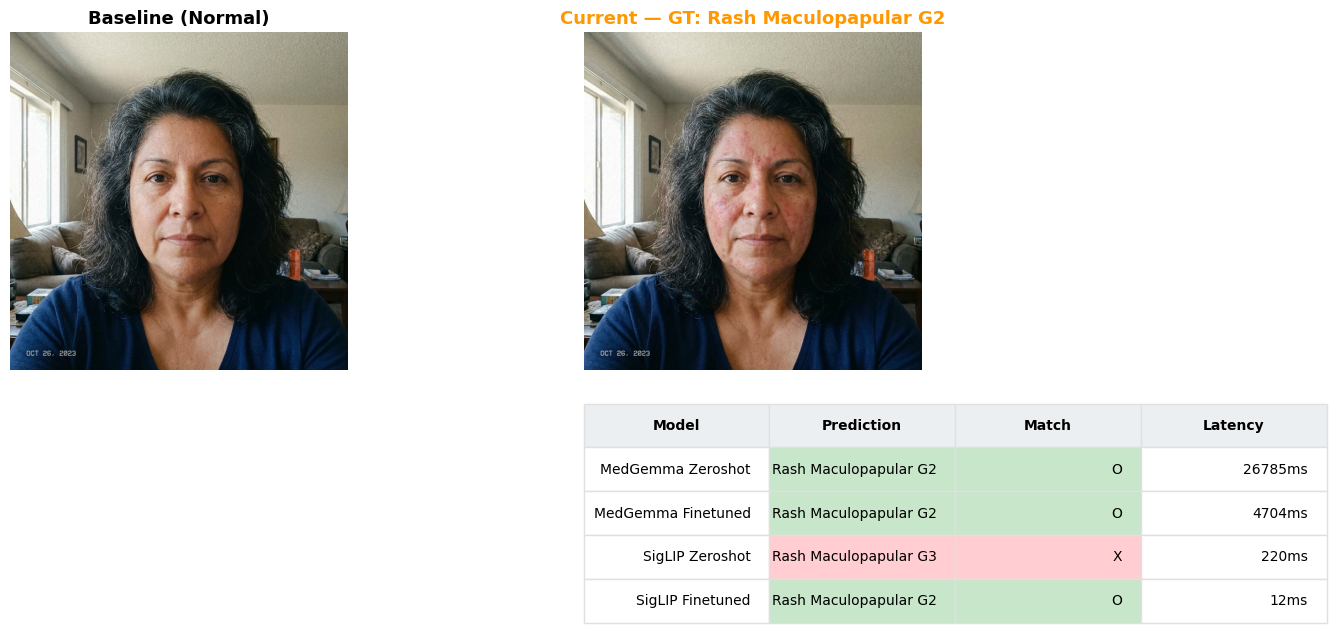

  [MedGemma Zeroshot] rash_maculopapular G2 — The patient presents with a new rash characterized by red macules and papules on the cheeks, forehead, and chin in Image
  [MedGemma Finetuned] rash_maculopapular G2 — Compared to baseline (Image 1), Image 2 shows Visible red macules/papules spreading across cheeks and forehead (10–30% B



In [7]:
_ = run_all_models("normal_8.png", "rash_maculopapular_g2_8.png", "rash_maculopapular_g2")

### 5-2. Normal (No Change)

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


Baseline: normal_9.png  |  Current: normal_9.png  |  GT: normal
--------------------------------------------------------------------------------


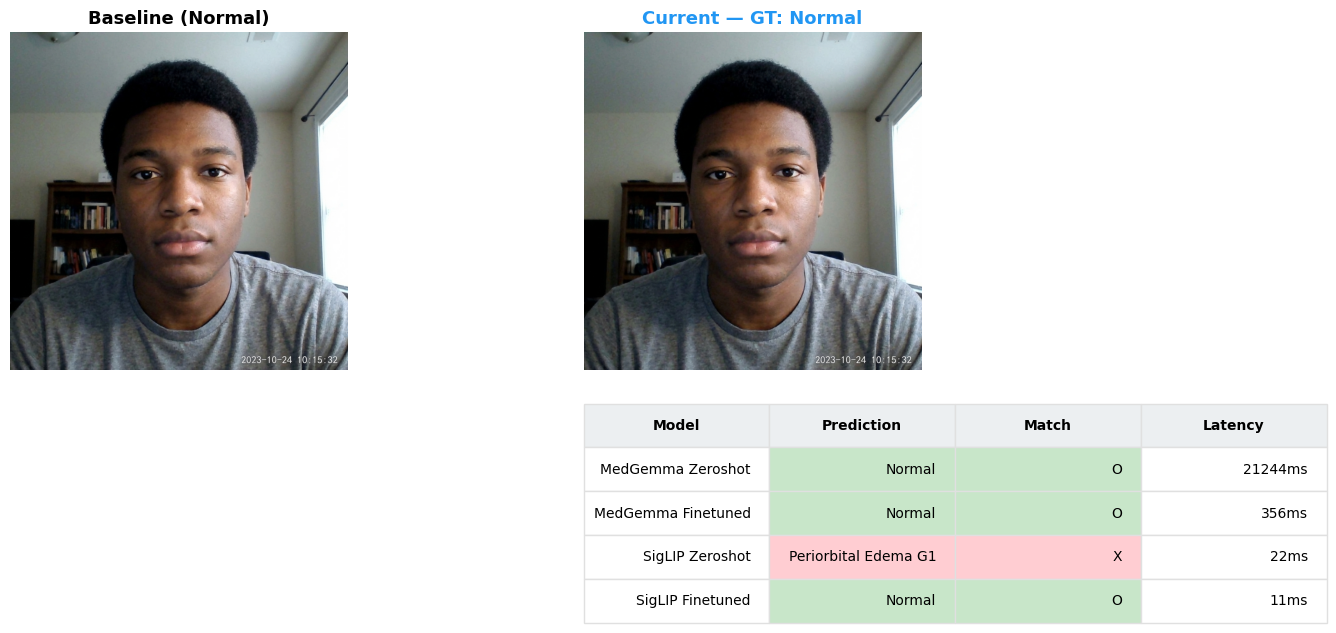

  [MedGemma Zeroshot] Normal — No AE detected
  [MedGemma Finetuned] Normal — No AE detected



In [8]:
_ = run_all_models("normal_9.png", "normal_9.png", "normal")

### 5-3. SJS Prodrome Grade 3 (Severe)

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


Baseline: normal_8.png  |  Current: sjs_prodrome_g3_8.png  |  GT: sjs_prodrome_g3
--------------------------------------------------------------------------------


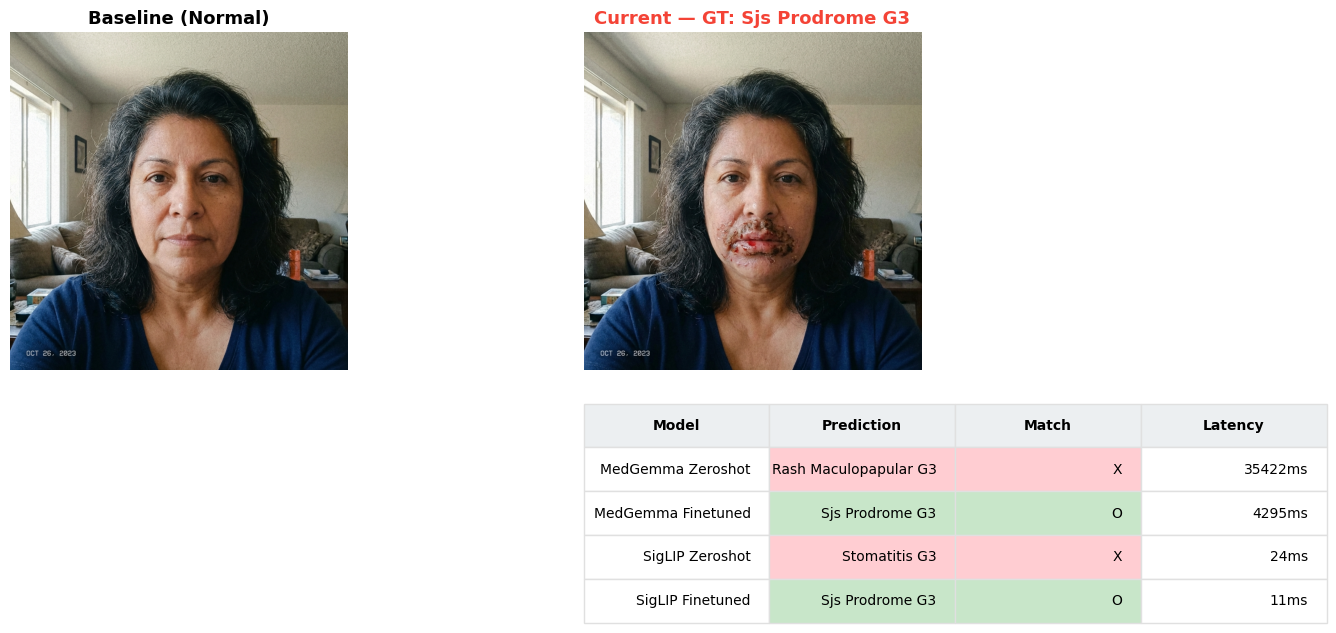

  [MedGemma Zeroshot] rash_maculopapular G3 — The patient has developed a severe, red, inflamed rash with possible vesicles/erosions and crusting around the mouth, wh
  [MedGemma Finetuned] sjs_prodrome G3 — Compared to baseline (Image 1), Image 2 shows Beginning of epidermal detachment on lips and perioral skin; large erosion



In [9]:
_ = run_all_models("normal_8.png", "sjs_prodrome_g3_8.png", "sjs_prodrome_g3")

### 5-4. Periorbital Edema Grade 1 (Mild)

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


Baseline: normal_8.png  |  Current: periorbital_edema_g1_8.png  |  GT: periorbital_edema_g1
--------------------------------------------------------------------------------


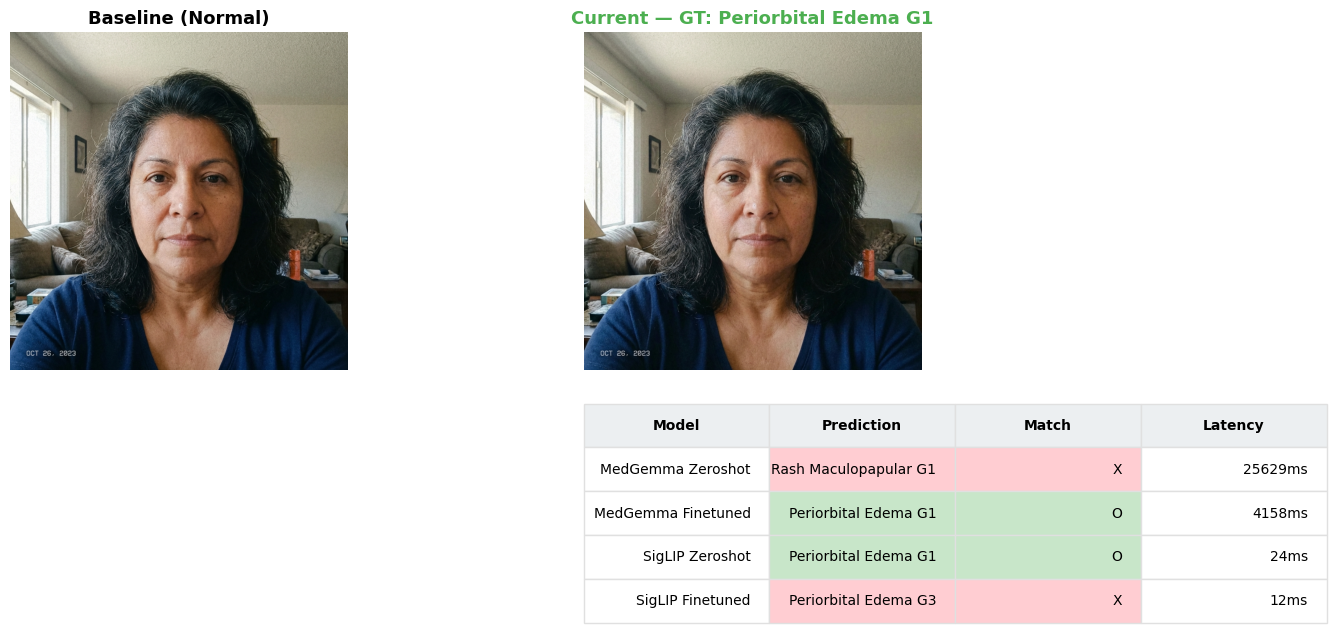

  [MedGemma Zeroshot] rash_maculopapular G1 — New presence of multiple small, reddish papules on the cheeks in Image 2 compared to Image 1.
  [MedGemma Finetuned] periorbital_edema G1 — Compared to baseline (Image 1), Image 2 shows Slight puffiness of upper and lower eyelids, barely noticeable; periorbita



In [10]:
_ = run_all_models("normal_8.png", "periorbital_edema_g1_8.png", "periorbital_edema_g1")

### 5-5. Alopecia Grade 2

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


Baseline: normal_9.png  |  Current: alopecia_g2_9.png  |  GT: alopecia_g2
--------------------------------------------------------------------------------


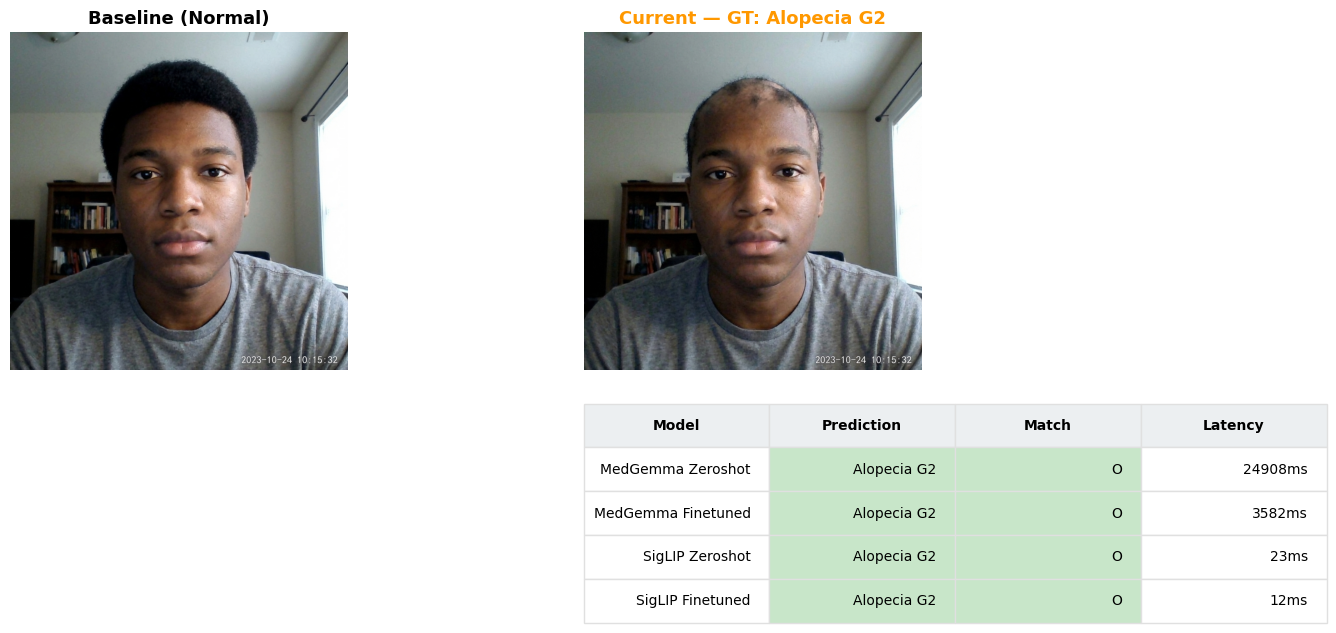

  [MedGemma Zeroshot] alopecia G2 — The patient's hair is significantly thinned, revealing the scalp, which was not present in the baseline image (Image 1).
  [MedGemma Finetuned] alopecia G2 — Compared to baseline (Image 1), Image 2 shows Obvious diffuse hair thinning with clearly visible scalp through hair; tem



In [11]:
_ = run_all_models("normal_9.png", "alopecia_g2_9.png", "alopecia_g2")

## 6. Batch Test — Full Test Set Comparison

Test set 42장 전체에 대해 4개 모델을 실행하고, Zeroshot vs Finetuned 정확도를 비교합니다.

In [12]:
test_entries = [e for e in metadata["images"] if e["split"] == "test"]
print(f"Test entries: {len(test_entries)}")

all_results = []

for i, entry in enumerate(test_entries):
    pkey = f"{entry['profile']['age']}/{entry['profile']['sex']}/{entry['profile']['race']}"
    baseline_file = baseline_map.get(pkey)
    if not baseline_file:
        continue

    bp = IMAGE_DIR / baseline_file
    cp = IMAGE_DIR / entry["file"]
    gt = entry["class_name"]

    r_gz = predict_gemma(bp, cp, gemma_zeroshot, "GemmaZS")
    r_gf = predict_gemma(bp, cp, gemma_finetuned, "GemmaFT")
    r_sz = predict_siglip_zeroshot(cp)
    r_sf = predict_siglip_finetuned(cp)

    row = {
        "file": entry["file"], "gt": gt,
        "gemma_zs": r_gz["pred_class"], "gemma_ft": r_gf["pred_class"],
        "siglip_zs": r_sz["pred_class"], "siglip_ft": r_sf["pred_class"],
    }
    all_results.append(row)

    marks = "".join("O" if row[k] == gt else "X" for k in ["gemma_zs", "gemma_ft", "siglip_zs", "siglip_ft"])
    print(f"[{i+1:2d}/{len(test_entries)}] {marks}  gt={gt:<28} "
          f"GZ={r_gz['pred_class']:<24} GF={r_gf['pred_class']:<24} "
          f"SZ={r_sz['pred_class']:<24} SF={r_sf['pred_class']}")

# Summary
n = len(all_results)
print(f"\n{'Model':<22} {'Accuracy':>10} {'Correct':>10}")
print("-" * 45)
for key, label in [("gemma_zs", "MedGemma Zeroshot"), ("gemma_ft", "MedGemma Finetuned"),
                    ("siglip_zs", "SigLIP Zeroshot"), ("siglip_ft", "SigLIP Finetuned")]:
    correct = sum(1 for r in all_results if r[key] == r["gt"])
    print(f"{label:<22} {correct/n*100:>8.1f}%  {correct:>5}/{n}")

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


Test entries: 42


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


[ 1/42] XOXO  gt=normal                       GZ=rash_maculopapular_g1    GF=normal                   SZ=periorbital_edema_g1     SF=normal


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


...

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


[40/42] XOXO  gt=alopecia_g1                  GZ=rash_maculopapular_g1    GF=alopecia_g1              SZ=periorbital_edema_g1     SF=alopecia_g1


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


[41/42] OOOO  gt=alopecia_g2                  GZ=alopecia_g2              GF=alopecia_g2              SZ=alopecia_g2              SF=alopecia_g2


[42/42] OOOO  gt=alopecia_g2                  GZ=alopecia_g2              GF=alopecia_g2              SZ=alopecia_g2              SF=alopecia_g2

Model                    Accuracy    Correct
---------------------------------------------
MedGemma Zeroshot          19.0%      8/42
MedGemma Finetuned         90.5%     38/42
SigLIP Zeroshot            28.6%     12/42
SigLIP Finetuned           61.9%     26/42


### 6-1. Accuracy Comparison (Zeroshot vs Finetuned)

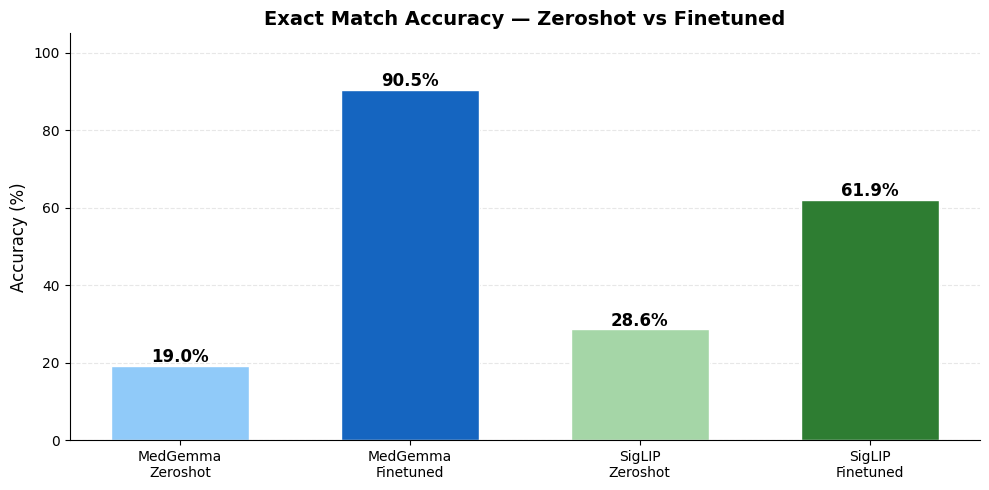

In [13]:
n = len(all_results)
models = {
    "MedGemma\nZeroshot": sum(1 for r in all_results if r["gemma_zs"] == r["gt"]) / n * 100,
    "MedGemma\nFinetuned": sum(1 for r in all_results if r["gemma_ft"] == r["gt"]) / n * 100,
    "SigLIP\nZeroshot": sum(1 for r in all_results if r["siglip_zs"] == r["gt"]) / n * 100,
    "SigLIP\nFinetuned": sum(1 for r in all_results if r["siglip_ft"] == r["gt"]) / n * 100,
}

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#90CAF9", "#1565C0", "#A5D6A7", "#2E7D32"]
bars = ax.bar(models.keys(), models.values(), color=colors, edgecolor="white", width=0.6)

for bar, val in zip(bars, models.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{val:.1f}%", ha="center", fontsize=12, fontweight="bold")

ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_title("Exact Match Accuracy — Zeroshot vs Finetuned", fontsize=14, fontweight="bold")
ax.set_ylim(0, 105)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, alpha=0.3, linestyle="--")
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### 6-2. Per-AE-Type Detection Rate Comparison

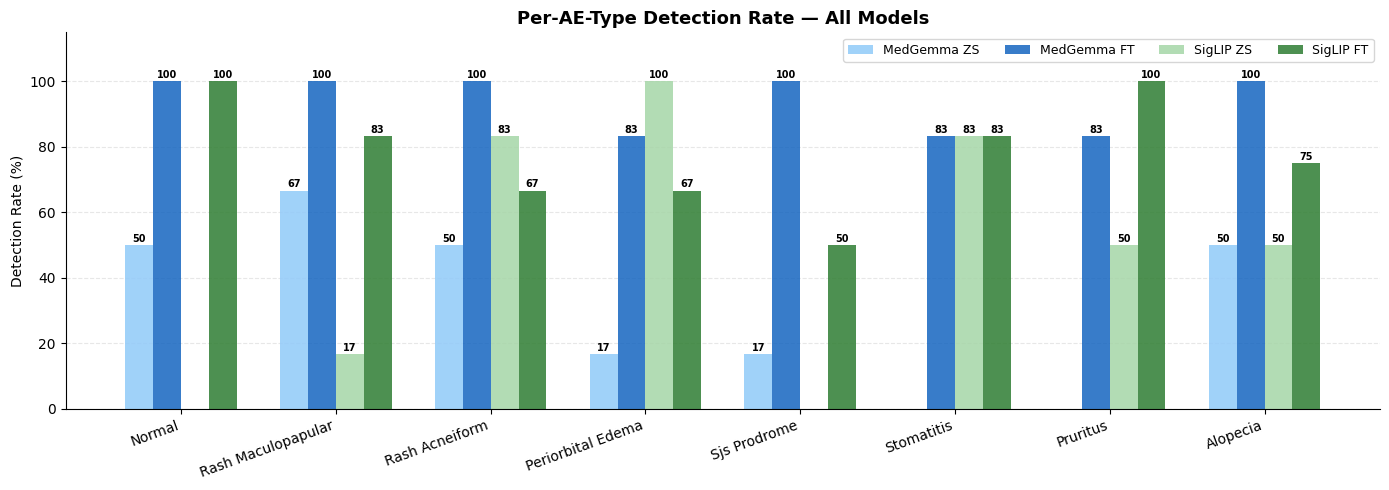

In [14]:
ae_types = ["normal", "rash_maculopapular", "rash_acneiform", "periorbital_edema",
            "sjs_prodrome", "stomatitis", "pruritus", "alopecia"]

model_keys = [("gemma_zs", "MedGemma ZS"), ("gemma_ft", "MedGemma FT"),
              ("siglip_zs", "SigLIP ZS"), ("siglip_ft", "SigLIP FT")]

# Compute per-AE detection rate for each model
ae_det_rates = {label: {} for _, label in model_keys}
for ae in ae_types:
    subset = [r for r in all_results if _parse_ae_type(r["gt"]) == ae]
    if not subset:
        continue
    for key, label in model_keys:
        detected = sum(1 for r in subset if _parse_ae_type(r[key]) == ae)
        ae_det_rates[label][ae] = detected / len(subset) * 100

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(ae_types))
width = 0.18
colors = ["#90CAF9", "#1565C0", "#A5D6A7", "#2E7D32"]

for idx, (_, label) in enumerate(model_keys):
    vals = [ae_det_rates[label].get(ae, 0) for ae in ae_types]
    offset = (idx - 1.5) * width
    bars = ax.bar(x + offset, vals, width, label=label, color=colors[idx], alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 1,
                    f"{h:.0f}", ha="center", fontsize=7, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([ae.replace("_", " ").title() for ae in ae_types], rotation=20, ha="right")
ax.set_ylabel("Detection Rate (%)")
ax.set_title("Per-AE-Type Detection Rate — All Models", fontsize=13, fontweight="bold")
ax.set_ylim(0, 115)
ax.legend(ncol=4, fontsize=9, loc="upper right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, alpha=0.3, linestyle="--")
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## 7. Custom Image Inference

외부 이미지 경로를 직접 지정하여 4개 모델 비교 추론을 실행할 수 있습니다.

In [15]:
# baseline_image = "/path/to/your/baseline.png"
# current_image  = "/path/to/your/current.png"
# gt_label = "rash_maculopapular_g2"  # or "normal"
#
# _ = run_all_models(
#     Path(baseline_image).name, Path(current_image).name, gt_label
# )
#
# Or run individual models:
# r = predict_gemma(baseline_image, current_image, gemma_finetuned, "Finetuned")
# r = predict_siglip_finetuned(current_image)